Confusion Matrix: Train Data
[[40  0  0]
 [ 0 39  2]
 [ 0  1 38]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.97      0.95      0.96        41
           2       0.95      0.97      0.96        39

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120

Confusion Matrix: Test Data
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



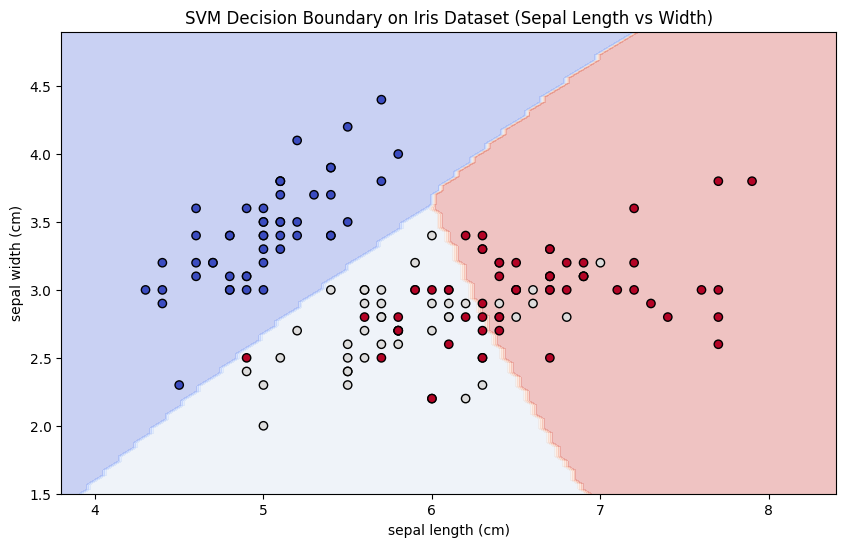

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target  # Target labels

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
#print(iris_df.head())
#print(iris_df.describe())
#iris_df.info()
#print(iris.DESCR)
iris_df['species'] = y

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an SVM classifier
#svm_model = SVC(kernel='linear')  # Using a linear kernel
#svm_model = SVC(kernel='sigmoid')
#svm_model = SVC(kernel='poly', degree=3, coef0=1)
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix: Train Data")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))
print("============================================================================")
# Evaluate the model
print("Confusion Matrix: Test Data")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

X_2D = iris.data[:, :2]  # Use sepal length and width
y_2D = iris.target

#svm_model_2D = SVC(kernel='linear')
#svm_model_2D = SVC(kernel='sigmoid')
#svm_model_2D = SVC(kernel='poly', degree=3, coef0=1)
svm_model_2D = SVC(kernel='rbf')
svm_model_2D.fit(X_2D, y_2D)

# Create a mesh grid
xx, yy = np.meshgrid(np.linspace(X_2D[:, 0].min() - 0.5, X_2D[:, 0].max() + 0.5, 100),
                     np.linspace(X_2D[:, 1].min() - 0.5, X_2D[:, 1].max() + 0.5, 100))
Z = svm_model_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y_2D, edgecolors='k', cmap='coolwarm')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("SVM Decision Boundary on Iris Dataset (Sepal Length vs Width)")
plt.show()